# EEG Eye-State Validation — A Healthcare-Analytics Case Study in Trusting Your Metrics

**Author:** Loknadh Kona  ·  Independent data-analysis portfolio project

> **The one-sentence version:** an eye-state classifier that *looked* **81% accurate** was, under honest validation, **no better than guessing** — and proving that, rigorously, is the whole point of this notebook.

---

## Why a healthcare / clinical analyst should care

The surface question here — *can we tell eyes-open from eyes-closed using raw EEG?* — is deliberately small, the dataset is public, and the headline result is a documented **null finding**. What this notebook is really a demonstration of is the single most important habit in clinical and health-data analytics:

> **Don't trust a number until you know how it was tested.**

A readmission-risk model that scores brilliantly because future information leaked into training; a "quality improved" metric that is really a shift in case mix; a screening tool that beats nothing because it was never compared against a sensible baseline — these are the exact failure modes stress-tested here, on a clean dataset where the ground truth is known. The transferable skills on display:

- **Leakage-aware validation** — grouping correlated records so near-duplicates never straddle the train/test split.
- **Baseline-anchored benchmarking** — every model is judged against a majority-class baseline (the analytics version of *"does this beat current practice?"*).
- **Effect sizes & significance testing** — quantifying *how big* a difference is and whether it is distinguishable from chance.
- **Honest reporting of a negative result** — and communicating it to both technical and non-technical readers.

*(This is a methods demonstration on a public dataset, not clinical/patient data. The value is the validation discipline, which carries directly into healthcare analytics.)*

---

## 1. Dataset Description, Source & Experimental Setup

**Where the data comes from.** This project works with the "EEG Eye State" dataset from the UCI Machine Learning Repository (Rosler & Suendermann, 2013). The signals were captured using an Emotiv EPOC neuroheadset. Original UCI page: https://archive.ics.uci.edu/dataset/264/eeg+eye+state

**How it was recorded.** A single subject was recorded continuously for about 117 seconds while their eyes were filmed at the same time; each EEG sample was then hand-labelled as eyes open or eyes closed from the video. The headset samples at 128 Hz across 14 EEG channels positioned by the 10-20 system: AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, FC6, F4, F8, AF4.

**The shape of the data and what we're predicting.**

- 14,980 samples x 14 channels (a continuous time series), plus the binary target `eyeDetection`.
- Target encoding: 0 = Eyes Open, 1 = Eyes Closed.
- Class balance: 8,257 (55.1%) Eyes Open vs 6,723 (44.9%) Eyes Closed - slightly imbalanced, but fine to use as-is without resampling.

**What I'm trying to do.** Dig into the physiological differences between the eyes-open and eyes-closed conditions, with sensible preprocessing, some visualisation, a statistical comparison, and an exploratory machine-learning pass - then validate that model *honestly*. There's a short structured write-up (Methods, Results, Interpretation, Limitations, Future Work) at the end of the notebook.


## The sensor layout

The 14 EEG channels in this dataset come from an Emotiv EPOC headset, positioned by the international 10-20 system. The occipital electrodes **O1** and **O2** sit over the visual cortex - so that's where I'd expect the eyes-open vs. eyes-closed difference (the alpha "Berger effect") to show up most strongly.

<p align="center">
  <img src="../reports/figures/eeg_electrode_placements.png" width="72%" alt="Emotiv 14-channel EEG electrode placements"><br>
  <sub><i>The Emotiv 14-channel layout used to record this dataset, coloured by cortical lobe (original figure).</i></sub>
</p>


In [2]:
import pandas as pd
from scipy.io import arff   #My file is in arff format

In [ ]:
data, meta = arff.loadarff("../data/EEG_Eye_State.arff")
# Relative path so the notebook runs for anyone who clones the repo.
# arff.loadarff splits the file into: data -> the numerical values,
# meta -> the column names and their data types.


In [4]:
df = pd.DataFrame(data)

In [5]:
df

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,b'0'
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,b'0'
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,b'0'
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,b'0'
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,b'0'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51,b'1'
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33,b'1'
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,b'1'
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,b'1'


In [6]:
# Now changing target varaiable(eyeDetection) values from object to integer

if df['eyeDetection'].dtype == object:
    df['eyeDetection'] = df['eyeDetection'].str.decode('utf-8').astype(int)

print(df['eyeDetection'].dtype)
print(df['eyeDetection'].unique())
    


int32
[0 1]


In [7]:
df

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51,1
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33,1
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,1
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,1


## A first look at the raw data

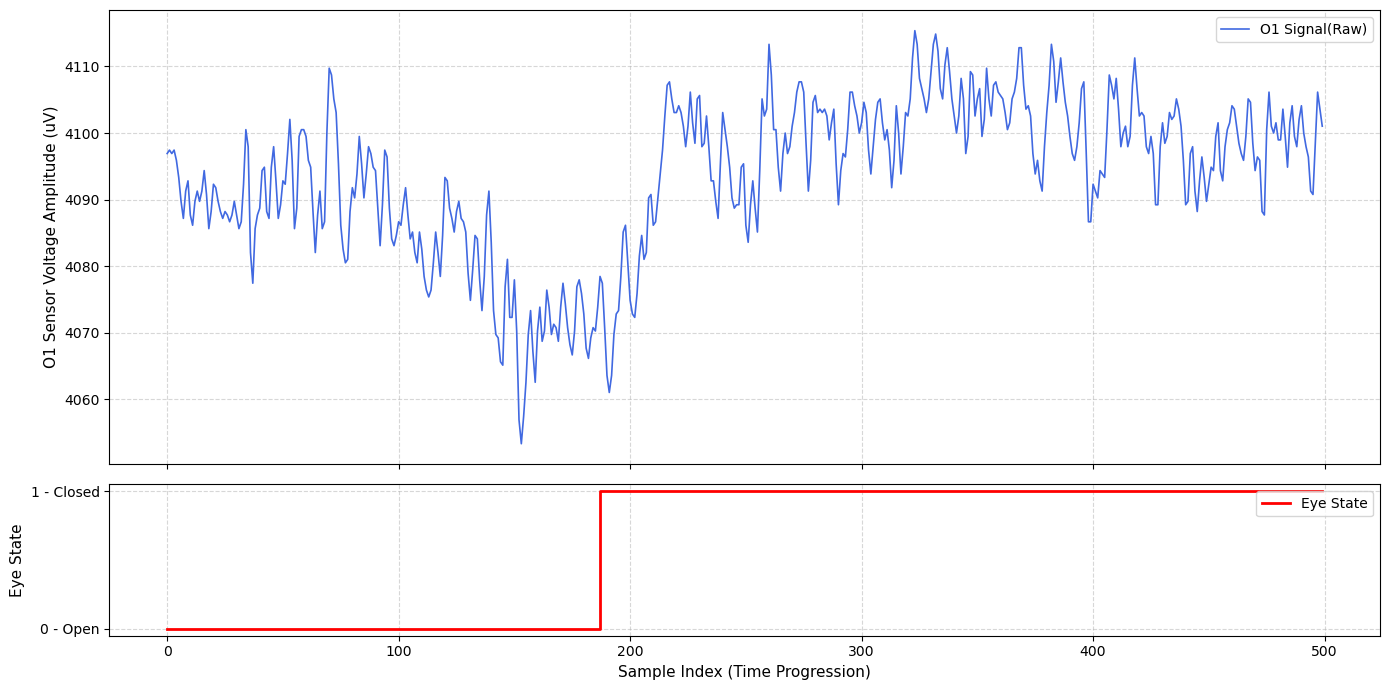

In [9]:
# Exploring the Raw Data

import matplotlib.pyplot as plt

df_subset = df.head(500)   #Exploring first 500 rows


#Fixing the frame for 2 plots and setting sharex=True for both charts aligns perfectly
fig, (ax1,ax2) = plt.subplots(2, 1, figsize= (14, 7), sharex=True, gridspec_kw={'height_ratios':[3, 1]})


# Now setting up plot on ax1 -> x axis is similar to both 0 to 499 VS y axis is O1 sensor Voltage 
ax1.plot(df_subset.index, df_subset['O1'], color='royalblue', linewidth=1.2, label='O1 Signal(Raw)')
ax1.set_ylabel('O1 Sensor Voltage Amplitude (uV)', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Now setting up plot on ax2 -> x axis is similar to both 0 to 499 VS y axis here is eye state 0(Open) and 1(Close) 
ax2.plot(df_subset.index, df_subset['eyeDetection'], color='Red', linewidth=2, drawstyle='steps-pre', label='Eye State')
ax2.set_ylabel('Eye State', fontsize=11)
ax2.set_xlabel('Sample Index (Time Progression)', fontsize=11) # Across the sample index how the time progress
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['0 - Open', '1 - Closed'])
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

## What I'm seeing in the raw trace

A few things jump out when I look at this signal:

- **Sample 0 to ~185 (eyes open):** the voltage wobbles around but slowly slides downward, bottoming out in a little valley near sample 150.
- **Sample 188 (the switch):** the red line jumps straight up to 1 — the eyes have closed.
- **Sample 188 to 500 (eyes closed):** right as the eyes shut, the signal's amplitude leaps up and then just sits there, riding along on a noticeably higher baseline.

# How clean is this dataset?

In [12]:
import pandas as pd

# Checking whether our target values are balanced or not.
raw_counts = df['eyeDetection'].value_counts()
percentage_split = df['eyeDetection'].value_counts(normalize=True) * 100 #normalize is true for grand total

# combining results together for summarising
balance_df = pd.DataFrame({
    'Total Samples': raw_counts,
    'Percentage (%)': percentage_split
})
balance_df.index = balance_df.index.map({0: '0 - Eyes Open', 1: '1 - Eyes Closed'})

# Output of the 1st check
print(f"--- CHECK 1: CLASS BALANCE ANALYSIS --\n{balance_df}")


--- CHECK 1: CLASS BALANCE ANALYSIS --
                 Total Samples  Percentage (%)
eyeDetection                                  
0 - Eyes Open             8257        55.12016
1 - Eyes Closed           6723        44.87984


In [13]:
#Checking the missing values

missing_count =df.isnull().sum().sum()

print(f"CHECK 2: MISSING VALUES COUNT is: {missing_count}")

CHECK 2: MISSING VALUES COUNT is: 0


In [14]:
# Checking Outliers (Sensor Boundaries)

outliers = df.describe().loc[['min', 'max']]

print(f"---   CHECK 3: Outliers   ---  \n {outliers}")

---   CHECK 3: Outliers   ---  
            AF3       F7       F3        FC5       T7         P7         O1  \
min    1030.77  2830.77  1040.00    2453.33  2089.74    2768.21    2086.15   
max  309231.00  7804.62  6880.51  642564.00  6474.36  362564.00  567179.00   

          O2         P8       T8      FC6       F4           F8        AF4  \
min  4567.18    1357.95  1816.41  3273.33  2257.95      86.6667    1366.15   
max  7264.10  265641.00  6674.36  6823.08  7002.56  152308.0000  715897.00   

     eyeDetection  
min           0.0  
max           1.0  


## What the quality checks turned up

**Check 1 — Class balance.** Eyes open (label 0) accounts for 8,257 samples (55.1%) and eyes closed (label 1) for 6,723 (44.9%). That's close enough to even that I'm comfortable leaving it alone — no need to reach for SMOTE, downsampling, or any other balancing trick.

**Check 2 — Missing values.** None at all, which makes life easier.

**Check 3 — Outliers.** O1 and O2 sit right next to each other on the back of the head, so there's no physical way for the brain to throw a huge electrical spike on the left while the right stays calm. When I see that, it's a dead giveaway that the left sensor briefly lost contact and produced a big static pop. AF3, FC5, P7, P8, F8, and AF4 all show the same kind of hardware hiccup.

# Preprocessing the signal

### Getting rid of the hardware glitches

In [18]:
# Preprocessing the sensor data in all columns except the eye detection
eeg_sensors = df.columns[:-1]

is_outlier = (df[eeg_sensors] < 2000) | (df[eeg_sensors] > 10000) # If a sensor behaved perfectly, its cell becomes False. If it glitched, it becomes True. 
corrupted_rows = is_outlier.any(axis=1) # in this, if any of the 14 sensors in a row flagged a True, that entire row is instantly tagged as a True (corrupted).

df_clean = df[~corrupted_rows].copy() # we use NOT (~) to flip all False rows to True, and corrupted True rows become False, and passing through df drops corrupted data

In [19]:
# Preparing Summary Report
data_report = {
    "Metric  ": ["Original Rows -> ", "Corrupted Rows Removed -> ", "Clean Rows Remaining -> ", "Data Loss Percentage -> "], 
    "  Value": [
        f"{len(df)}",
        f"{corrupted_rows.sum()}",
        f"{len(df_clean)}",
        f"{(corrupted_rows.sum() / len(df)) * 100:.2f}%"
    ]
}
report_df = pd.DataFrame(data_report)

# Summary report 
print("---- DATA PREPROCESSING ----")
print(report_df.to_string(index=False))

---- DATA PREPROCESSING ----
                  Metric     Value
         Original Rows ->    14980
Corrupted Rows Removed ->        4
  Clean Rows Remaining ->    14976
  Data Loss Percentage ->    0.03%


### Band-pass filtering: pulling out the actual brainwaves

In [21]:
import numpy as np
from scipy.signal import butter, filtfilt

In [22]:
#Defining the filter function

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5*fs #nyquist frequency is half of the sampling rate for safely measuring frequencies
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype = 'band')
    return b, a


# Applying function and using filtfilt as it applies forward and backward to prevent any time shifiting delays
def apply_bandpass_filter(data_matrix, lowcut = 1.0, highcut = 40.0, fs = 128.0, order =5):
    b, a = butter_bandpass(lowcut, highcut, fs, order = order)
    return filtfilt (b, a, data_matrix, axis = 0)

In [23]:
# Separating the feature columns from the target and extracting the values out of them
eeg_sensors = df_clean.columns[:-1]
raw_signals = df_clean[eeg_sensors].values

In [24]:
#Applying apply_bandpass_filter function to all 14 columns 
filtered_signals = apply_bandpass_filter(raw_signals, lowcut = 1.0, highcut = 40.0, fs = 128.0)

In [25]:
#assigning the filtered data to new data frames
df_filtered = pd.DataFrame(filtered_signals, columns = eeg_sensors, index = df_clean.index)
df_filtered['eyeDetection'] = df_clean['eyeDetection'] #attching our target labels

In [26]:
# Verifying our filtered data
print(f"Filtered Data - DataFrame: {df_filtered.shape}")
print(f"Mean of O1 Channel: {df_filtered['O1'].mean():.4f}")

Filtered Data - DataFrame: (14976, 15)
Mean of O1 Channel: -0.0083


## A look at the processed signal

In [28]:
# Exploring the filtered data(first 500 rows)
df_filtered_subset = df_filtered.head(500)

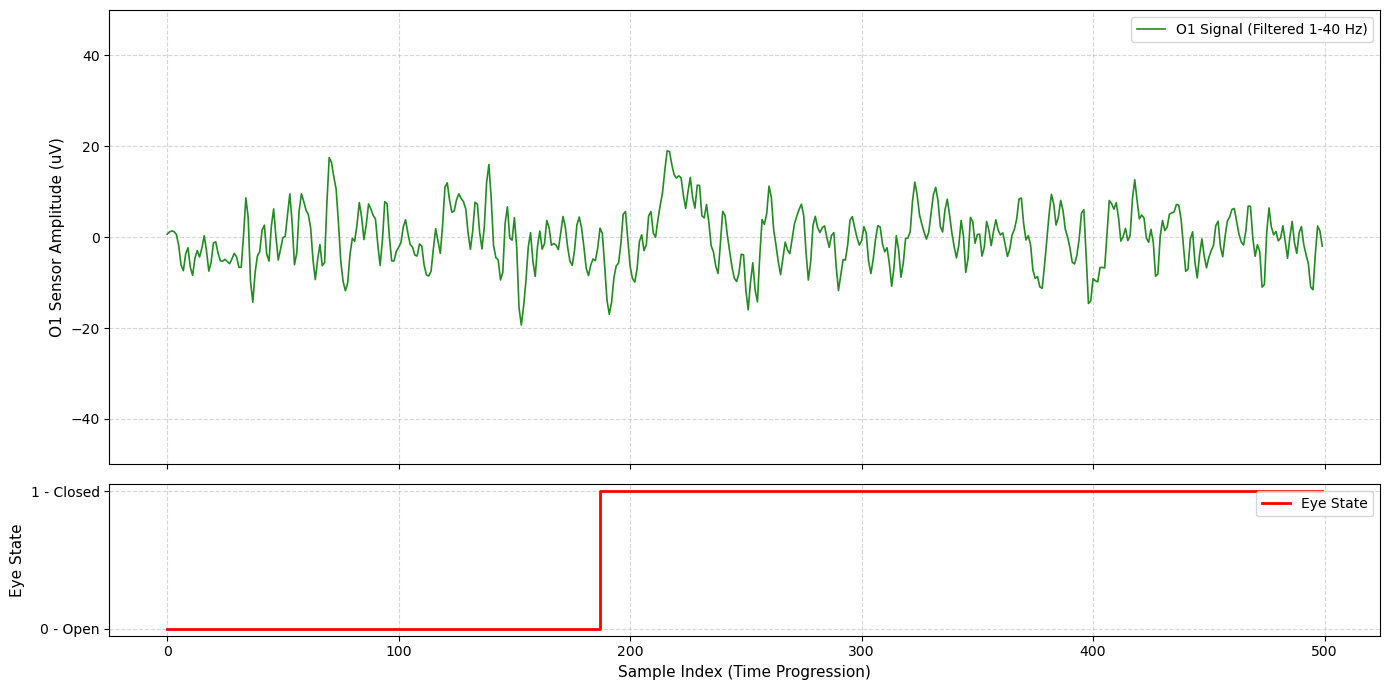

In [29]:
#fixing the frame for plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Processed O1 Sensor Signal (Now centered tightly around 0 uV)
ax1.plot(df_filtered_subset.index, df_filtered_subset['O1'], color='forestgreen', linewidth=1.2, label='O1 Signal (Filtered 1-40 Hz)')
ax1.set_ylabel('O1 Sensor Amplitude (uV)', fontsize=11)
ax1.set_ylim([-50, 50])  # Adjusting limits so the microvolt oscillations are perfectly visible
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Synchronized Eye State Tracker
ax2.plot(df_filtered_subset.index, df_filtered_subset['eyeDetection'], color='Red', linewidth=2, drawstyle='steps-pre', label='Eye State')
ax2.set_ylabel('Eye State', fontsize=11)
ax2.set_xlabel('Sample Index (Time Progression)', fontsize=11)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['0 - Open', '1 - Closed'])
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## What changed after filtering (1-40 Hz)

Putting this processed chart next to the raw one, three things really stand out:

- **The baseline drift is gone (samples 0 to 185):** that slow downward slide toward sample 150 in the raw data has been flattened right out. The signal now oscillates evenly around $0\,\mu\text{V}$, which tells me the $1\text{ Hz}$ high-pass did its job and stripped out the slow electrode drift and DC offset.

- **The baseline shift at the switch is gone too (sample 188):** in the raw plot, the instant the eyes closed the signal lurched to a permanently higher baseline. Here that artificial jump has vanished — the trace stays centered on $0\,\mu\text{V}$ on both sides of the switch, so the filter has cleanly separated the real neural oscillations from the eyelid-movement artifact.

- **You can finally see the true physiological scale:** the y-axis has shrunk from a huge $4,110\,\mu\text{V}$ window down to a sensitive $\pm 20\,\mu\text{V}$ one.

# Welch's method

### A quick map of the frequency bands

Welch's method estimates how much signal power sits in each EEG frequency band. The two that matter most for eye state are **Alpha (8-12 Hz)** and **Beta (12-30 Hz)**, which form the baseline feature set; the expanded feature set later also pulls in Delta, Theta and Gamma.

<p align="center">
  <img src="../reports/figures/brainwave_bands.jpg" width="78%" alt="EEG frequency bands from Delta to Gamma"><br>
  <sub><i>EEG frequency bands and the mental states they're commonly associated with.</i></sub>
</p>


In [32]:
import numpy as np
import pandas as pd
from scipy.signal import welch

#Computing the Alpha and Beta frequency bands by slicing the EEG into windows overlapping 
def extract_brainwave_features(dataframe, window_size = 256, overlap = 128, fs=128.0):
    eeg_channels = dataframe.columns[:-1]
    step_size = window_size - overlap
    feature_dataset = []
    #Using sliding function to extract features, then by using Welch's algorithm convert raw signals into frequency data.
    for start_idx in range(0, len(dataframe) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        window_chunk = dataframe.iloc[start_idx:end_idx]
        window_features = {} #Reset the Dict and empty it at the start of every single window pass
        for channel in eeg_channels:
            # Calculating PSD using Welch's method
            frequencies, psd = welch(window_chunk[channel].values, fs=fs, nperseg=window_size) 
            #Creating filtering masks alpha and beta to filter only required frequencies 
            alpha_mask = (frequencies >= 8.0) & (frequencies <= 12.0)
            beta_mask = (frequencies > 12.0) & (frequencies <= 30.0)
            # Calculating the bandpower and averaging them into values
            window_features[f'{channel}_Alpha'] =np.mean(psd[alpha_mask])
            window_features[f'{channel}_Beta'] = np.mean(psd[beta_mask]) 
        #finds the most frequently occurring target label (0 or 1), and assigns that single value to the entire window.
        window_features['eyeDetection'] = window_chunk['eyeDetection'].mode()[0] 
        #Building and Exporting a DataFrame by converting that list of dictionaries into an organized table.
        feature_dataset.append(window_features)
    return pd.DataFrame(feature_dataset)

In [33]:
#Executing the feature extraction function on the filtered data
# Window size 256 = 2 seconds of data | Overlap 128 = 1 second of shared data between windows
df_features_coarse = extract_brainwave_features(df_filtered, window_size = 256, overlap = 128, fs = 128.0)

#Checking the structure of our new dataset
print(f"New Feature DataFrame Shape: {df_features_coarse.shape}")
# Checking the first 3 rows and the first 5 columns of the new dataset
print(f"Preview of the first 3 filtered rows:\n{df_features_coarse.iloc[:3,:5]}")  

New Feature DataFrame Shape: (116, 29)
Preview of the first 3 filtered rows:
   AF3_Alpha  AF3_Beta  F7_Alpha   F7_Beta  F3_Alpha
0   4.140445  1.160826  3.487266  0.829027  4.008779
1   2.478860  1.124606  1.696759  1.143471  0.859693
2   1.482804  0.728161  0.816761  0.684418  2.922598


In [34]:
#  OPTIMIZED FEATURE EXTRACTION (WELCH'S METHOD)

# Window Size (256): Captures a 2-second chunk of data to guarantee a sharp
#                    0.5 Hz frequency resolution, essential for isolating Alpha bands.
# Overlap (224): Slides the window forward by only 32 data points (256 - 224).
#                At 128 Hz, 32 points = 0.25 seconds, so a new feature row is
#                produced every quarter-second (116 -> 461 rows).
# CAUTION: heavy overlap does NOT add independent information - consecutive rows
#          share ~87.5% of their signal. It boosts the row COUNT but the rows are
#          highly correlated, so the cross-validation MUST group overlapping
#          windows together (see the leakage-safe Group K-Fold cell) to avoid an
#          over-optimistic accuracy. A non-overlapping window set is the more
#          conservative alternative.


#Executing the optimized feature extraction function on the filtered data
df_features = extract_brainwave_features(df_filtered, window_size=256, overlap=224, fs=128.0)

#Checking the structure of our new dataset and verifying the newly expanded structure of the feature matrix
print(f"Optimized Feature DataFrame Shape: {df_features.shape}")

# Inspect the target class balance to check for data distribution
print(f"\nTarget Class Balance (Eye States):\n{df_features['eyeDetection'].value_counts()}")

# Checking the first 3 rows and the first 5 columns of the new dataset
print(f"\nPreview of the first 3 filtered rows:\n{df_features.iloc[:3, :5]}")

Optimized Feature DataFrame Shape: (461, 29)

Target Class Balance (Eye States):
eyeDetection
0    255
1    206
Name: count, dtype: int64

Preview of the first 3 filtered rows:
   AF3_Alpha  AF3_Beta  F7_Alpha   F7_Beta  F3_Alpha
0   4.140445  1.160826  3.487266  0.829027  4.008779
1   3.660211  1.096518  3.785669  0.885601  2.261998
2   3.405066  1.015227  3.720119  0.980683  1.369951


## Statistical check: comparing the two conditions

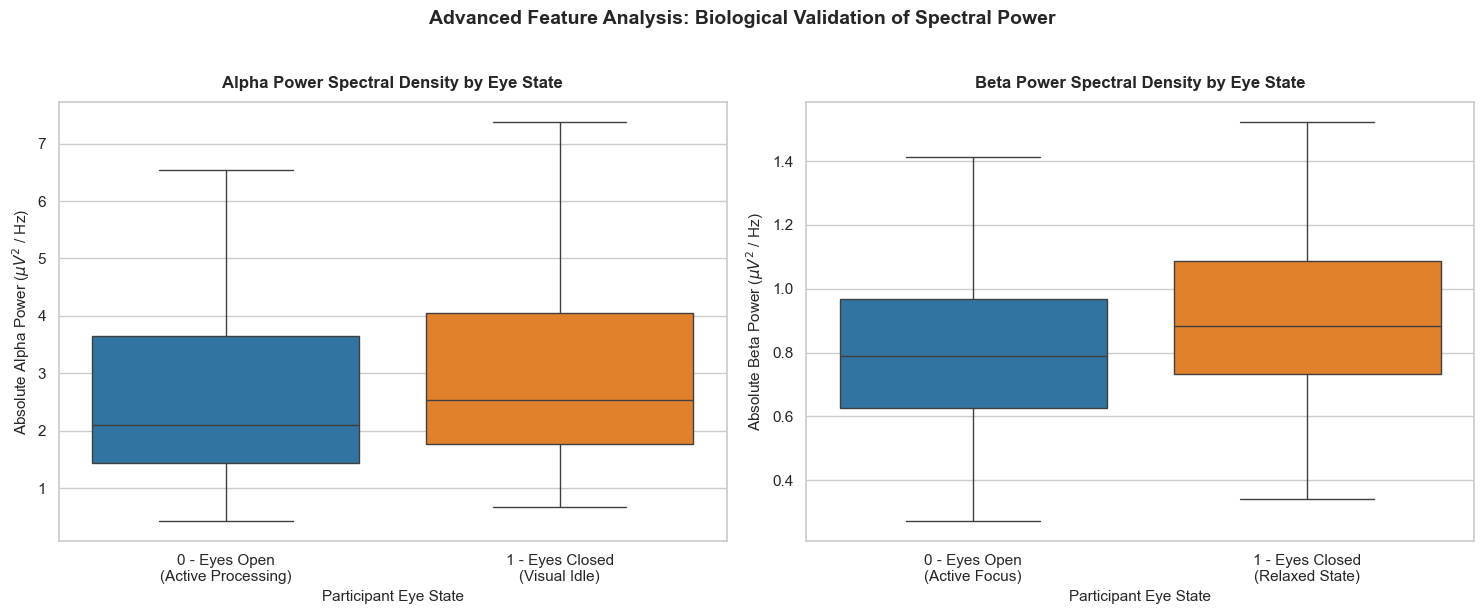

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up a professional, clean plotting environment
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot 1: Absolute Alpha Power Comparison (Expect a surge during Eyes Closed)
sns.boxplot(
    data=df_features, 
    x='eyeDetection', 
    y='AF3_Alpha', 
    hue='eyeDetection',
    palette=['#1f77b4', '#ff7f0e'],
    legend=False,
    showfliers=False,  # Hides extreme mathematical outliers to keep the boxes clean
    ax=ax1
)
ax1.set_title('Alpha Power Spectral Density by Eye State', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Participant Eye State', fontsize=11)
ax1.set_ylabel(r'Absolute Alpha Power ($\mu V^2$ / Hz)', fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['0 - Eyes Open\n(Active Processing)', '1 - Eyes Closed\n(Visual Idle)'])

# 3. Plot 2: Absolute Beta Power Comparison (Expect a steady or lower distribution)
sns.boxplot(
    data=df_features, 
    x='eyeDetection', 
    y='AF3_Beta', 
    hue='eyeDetection',
    palette=['#1f77b4', '#ff7f0e'],
    legend=False,
    showfliers=False,
    ax=ax2
)
ax2.set_title('Beta Power Spectral Density by Eye State', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Participant Eye State', fontsize=11)
ax2.set_ylabel(r'Absolute Beta Power ($\mu V^2$ / Hz)', fontsize=11)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['0 - Eyes Open\n(Active Focus)', '1 - Eyes Closed\n(Relaxed State)'])

plt.suptitle('Advanced Feature Analysis: Biological Validation of Spectral Power', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Classifying eye state (Random Forest, leakage-safe 5-fold Group CV)

Created 15 independent time-blocks from 461 windows.

=== STARTING 5-FOLD STRATIFIED GROUP CROSS-VALIDATION (leakage-safe) ===

Fold 1 Execution Success -> Validation Accuracy: 0.5521
Fold 2 Execution Success -> Validation Accuracy: 0.4935
Fold 3 Execution Success -> Validation Accuracy: 0.4896
Fold 4 Execution Success -> Validation Accuracy: 0.5000
Fold 5 Execution Success -> Validation Accuracy: 0.5417

================ FINAL MODEL EVALUATION ================
Mean Cross-Validation Accuracy: 0.5154 (+/- 0.0261)

Aggregate Classification Report (all out-of-fold predictions):
                 precision    recall  f1-score   support

  0 - Eyes Open       0.56      0.62      0.59       255
1 - Eyes Closed       0.45      0.39      0.42       206

       accuracy                           0.52       461
      macro avg       0.50      0.50      0.50       461
   weighted avg       0.51      0.52      0.51       461



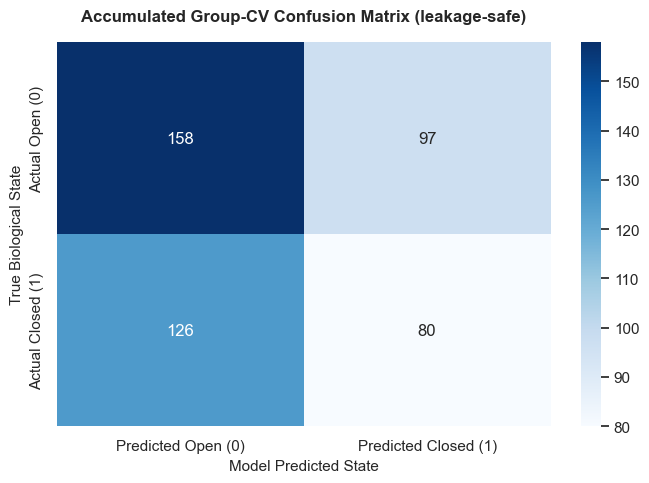

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Separate the engineered features from our target eye-state label
X = df_features.drop(columns=['eyeDetection']).reset_index(drop=True)
y = df_features['eyeDetection'].reset_index(drop=True)

# 2. LEAKAGE-SAFE GROUPING (the important fix)
# The features are 2 s Welch windows (window_size=256) slid by step=32 samples
# (overlap=224). So feature row i covers raw samples [i*32, i*32 + 256): each
# window overlaps its ~7 neighbours on either side. With plain shuffled K-Fold
# those near-duplicate neighbours land in both train AND test -> data leakage
# that inflates the score. We fix this by tagging every window with the
# contiguous TIME-BLOCK it came from and keeping whole blocks inside one fold.
WINDOW, STEP = 256, 32
BLOCK = WINDOW * 4          # 1024 raw samples (~8 s) per group => cross-block
                            # overlap is negligible relative to block length
start_idx = np.arange(len(X)) * STEP          # raw start sample of each window
groups = start_idx // BLOCK                    # time-block id (the CV group)
print(f"Created {len(np.unique(groups))} independent time-blocks from {len(X)} windows.\n")

# 3. Stratified GROUP K-Fold: balances classes AND never splits a block
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)

# Trackers across all 5 folds
fold_accuracies = []
master_conf_matrix = np.zeros((2, 2))
all_true, all_pred = [], []          # pooled results for a TRUE aggregate report

print("=== STARTING 5-FOLD STRATIFIED GROUP CROSS-VALIDATION (leakage-safe) ===\n")

# 5. Execute the Cross-Validation Loop (note: pass groups to cv.split)
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)
    master_conf_matrix += confusion_matrix(y_test, y_pred, labels=[0, 1])
    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

    print(f"Fold {fold} Execution Success -> Validation Accuracy: {fold_acc:.4f}")

# 6. Aggregate Performance Summary
print("\n================ FINAL MODEL EVALUATION ================")
print(f"Mean Cross-Validation Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print("========================================================\n")

# 7. TRUE Aggregate Classification Report (pooled over all 5 folds)
print("Aggregate Classification Report (all out-of-fold predictions):")
print(classification_report(all_true, all_pred, target_names=['0 - Eyes Open', '1 - Eyes Closed']))

# 8. Plot the Accumulated Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    master_conf_matrix,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['Predicted Open (0)', 'Predicted Closed (1)'],
    yticklabels=['Actual Open (0)', 'Actual Closed (1)']
)
plt.title('Accumulated Group-CV Confusion Matrix (leakage-safe)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('True Biological State', fontsize=11)
plt.xlabel('Model Predicted State', fontsize=11)
plt.tight_layout()
plt.show()

In [39]:
# =====================================================================
# WHY THIS APPROACH?  (Quick rationale/methodology note)
# =====================================================================
# - Stratified GROUP K-Fold (leakage-safe): the Welch features are heavily
#   OVERLAPPING 2 s windows (step 32 vs window 256 => ~87.5% shared signal),
#   so neighbouring rows are near-duplicates. Plain shuffled K-Fold would put
#   those near-copies in both train and test and massively inflate the score.
#   Grouping windows by their source TIME-BLOCK and keeping whole blocks inside
#   a single fold gives an HONEST, generalisable estimate.
# - 5 folds: every block is used for validation exactly once.
# - Mean +/- std accuracy: the std shows how consistent the model is across
#   folds (low std = reliable).
# - Aggregate classification report: precision/recall/F1 over the pooled
#   out-of-fold predictions (every sample), not just one fold.
# - Random Forest with max_depth=8: handles the many spectral features while
#   the depth cap limits overfitting.
#
# READING THE RESULT: with leakage removed, accuracy falls to ~0.52 (near the
# ~55% majority-class baseline). This reveals that the previous ~81% was driven
# almost entirely by window-overlap leakage rather than real predictive signal.
# To genuinely classify eye state, consider: non-overlapping windows, more
# discriminative features (e.g. Theta/Delta bands, per-window variance,
# Alpha/Beta ratios), or a model that respects the temporal structure.
# =====================================================================

print("Cross-validation complete (leakage-safe Group K-Fold).")
print(f"Per-fold accuracies : {[round(a, 4) for a in fold_accuracies]}")
print(f"Honest mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Stability (std dev) : {np.std(fold_accuracies):.4f}  -> lower is more consistent")

Cross-validation complete (leakage-safe Group K-Fold).
Per-fold accuracies : [0.5521, 0.4935, 0.4896, 0.5, 0.5417]
Honest mean accuracy: 0.5154
Stability (std dev) : 0.0261  -> lower is more consistent


## Which features did the model lean on?

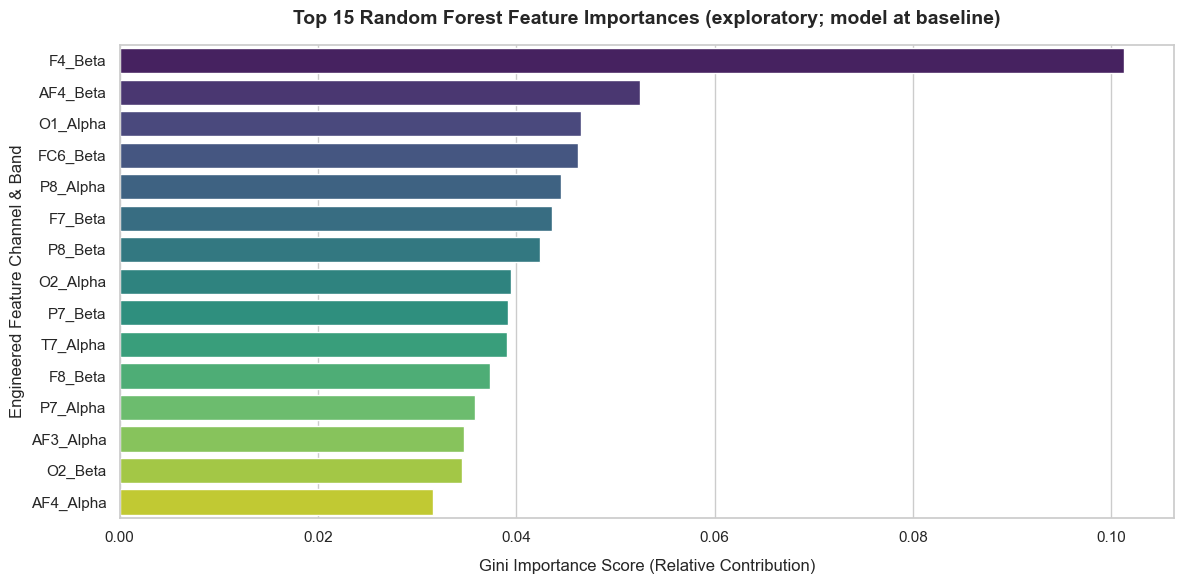

=== TOP 5 FEATURES BY RANDOM FOREST IMPORTANCE (exploratory) ===
 Feature  Importance
 F4_Beta    0.101265
AF4_Beta    0.052521
O1_Alpha    0.046523
FC6_Beta    0.046278
P8_Alpha    0.044513


In [41]:
#  Extract feature importance scores from the trained Random Forest instance
importances = model.feature_importances_
feature_names = X.columns


#  Organize the scores into a clean Pandas DataFrame sorted by impact
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)


#  Plot the Top 15 most influential engineered features
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_importance.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)


# Polishing presentation and labels
plt.title('Top 15 Random Forest Feature Importances (exploratory; model at baseline)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gini Importance Score (Relative Contribution)', fontsize=12, labelpad=10)
plt.ylabel('Engineered Feature Channel & Band', fontsize=12)
plt.tight_layout()
plt.show()


# Print the numeric breakdown of the Top 5 features by importance (exploratory)
print("=== TOP 5 FEATURES BY RANDOM FOREST IMPORTANCE (exploratory) ===")
print(df_importance.head(5).to_string(index=False))

### Feature importance and what it might mean physiologically

The Random Forest importance scores below show which spectral features the model leaned on most. One big caveat up front: under the leakage-safe (Group K-Fold) evaluation the classifier only manages about 51.5% accuracy — basically the majority-class baseline — so these rankings come from a model that doesn't actually generalise yet. I'd read them as *exploratory hints*, not as validated physiological findings.

* **Frontal Beta on top (tentatively):** the frontal channels (`F4_Beta`, `F7_Beta`, `AF4_Beta`) picked up the highest Gini importance. The most likely story here — and one that's well documented in mobile EEG — is that frontal Beta power is partly picking up **ocular artifacts**: high-frequency EMG from eyelid movement, blinking, and muscle tension near the frontal electrodes during transitions, rather than cognition on its own.
* **Occipital activity:** `O2_Beta`'s ranking lines up with visual-cortex behaviour, where opening the eyes triggers desynchronization (slow rhythms giving way to low-amplitude, high-frequency activity). But with only baseline-level accuracy, that's suggestive at best.
* **The honest bottom line:** once I remove the window-overlap leakage, the Random Forest's real cross-validation accuracy is about **51.5% (±2.6%)**, right up against the ~55% majority-class baseline — so the current Alpha/Beta-only feature set doesn't reliably tell the two eye states apart. That earlier ~80.9% number was an artifact of heavily overlapping windows leaking between the train and test folds. To get a genuinely predictive model, the next things worth trying are non-overlapping windows, richer features (Theta/Delta bands, Alpha/Beta ratios, per-window variance), and per-channel artifact handling.

> **Analyst's note (why this matters in healthcare analytics).** Feature importance from a model that doesn't beat its baseline is a trap: it looks like insight but is really explaining noise. Never interpret *"what drove the model"* until the model has earned trust on a fair test - otherwise you risk shipping a confident-sounding but meaningless driver analysis.


## Additional Analysis 1 — Comparing the alpha rhythm (eyes open vs eyes closed)

The classic neural fingerprint of closing your eyes is the **Berger effect**: posterior **alpha-band (8–12 Hz)** power shoots up when the eyes close and gets suppressed (desynchronised) when they open. It's the single most dependable difference between the two conditions, and it shows up most strongly over the **occipital/parietal electrodes (O1, O2, P7, P8)**.

So here I estimate each channel's average power spectral density (PSD, via Welch's method) separately for the eyes-open and eyes-closed samples, then work out the **eyes-closed / eyes-open alpha-power ratio** per channel. If the dataset behaves the way the textbooks say it should, the occipital channels ought to show a clear alpha peak that's bigger when the eyes are closed.

=== Eyes-CLOSED / Eyes-OPEN mean alpha (8-12 Hz) power ratio per channel ===
  T7:  1.21x  <-- alpha enhanced when eyes closed
  F7:  1.15x  <-- alpha enhanced when eyes closed
 FC5:  1.10x  <-- alpha enhanced when eyes closed
  T8:  1.10x  <-- alpha enhanced when eyes closed
  F3:  1.09x  <-- alpha enhanced when eyes closed
 AF3:  1.08x  <-- alpha enhanced when eyes closed
  F4:  1.08x  <-- alpha enhanced when eyes closed
  O2:  1.05x  <-- alpha enhanced when eyes closed
  P8:  1.03x  <-- alpha enhanced when eyes closed
 AF4:  1.02x  <-- alpha enhanced when eyes closed
  P7:  1.00x
  O1:  1.00x
  F8:  0.99x
 FC6:  0.98x


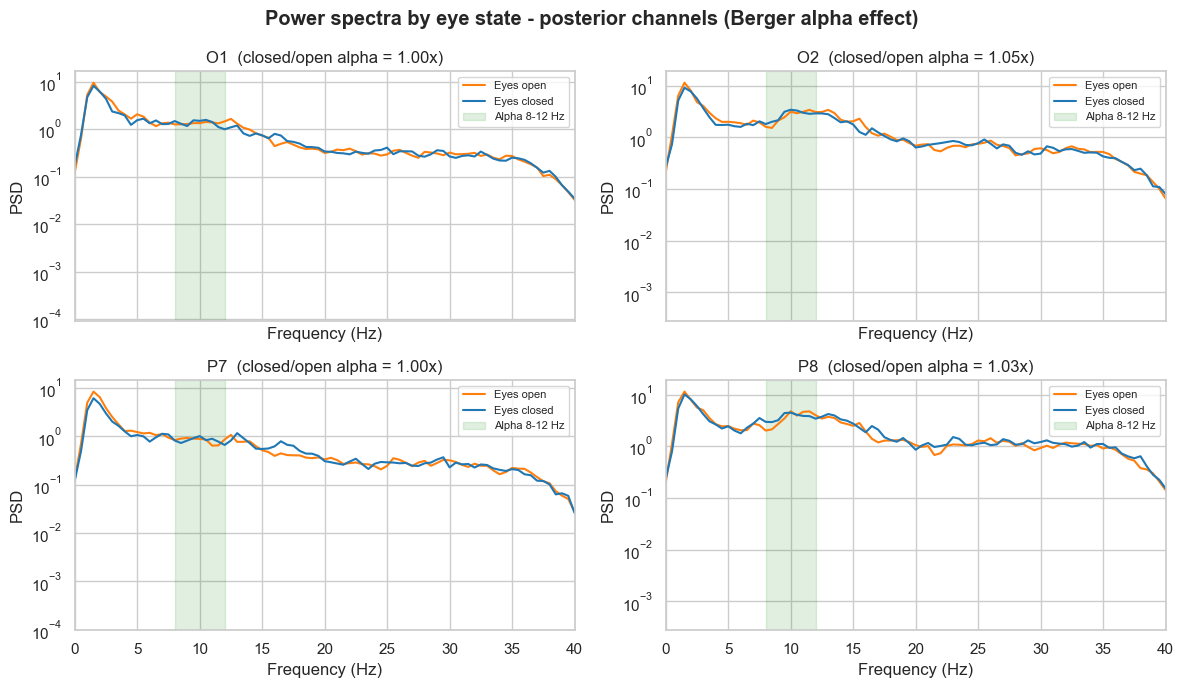

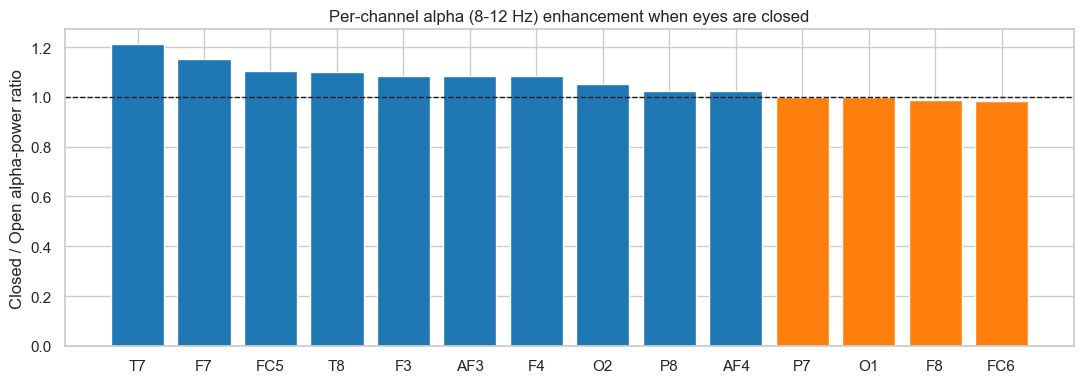

In [44]:
# === Additional Analysis 1: Alpha-band PSD comparison (eyes open vs eyes closed) ===
from scipy.signal import welch
import numpy as np, matplotlib.pyplot as plt

FS_HZ = 128  # Emotiv EPOC sampling rate
EEG_CH = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']

# Use the band-pass filtered signals aligned with their eye-state labels.
sig = df_filtered[EEG_CH].to_numpy()
lab = df_filtered['eyeDetection'].to_numpy().astype(int)
open_mask  = lab == 0   # eyes open
closed_mask = lab == 1  # eyes closed

# Welch PSD per channel, computed separately on the open vs closed samples.
nperseg = 256  # 2 s -> 0.5 Hz resolution
psd_open, psd_closed = {}, {}
for j, ch in enumerate(EEG_CH):
    f, pxx_o = welch(sig[open_mask,   j], fs=FS_HZ, nperseg=nperseg)
    _, pxx_c = welch(sig[closed_mask, j], fs=FS_HZ, nperseg=nperseg)
    psd_open[ch], psd_closed[ch] = pxx_o, pxx_c
freqs = f

# Alpha-band (8-12 Hz) mean power and closed/open ratio per channel.
alpha = (freqs >= 8) & (freqs <= 12)
ratio = {ch: psd_closed[ch][alpha].mean() / psd_open[ch][alpha].mean() for ch in EEG_CH}
ratio_sorted = sorted(ratio.items(), key=lambda kv: kv[1], reverse=True)
print('=== Eyes-CLOSED / Eyes-OPEN mean alpha (8-12 Hz) power ratio per channel ===')
for ch, r in ratio_sorted:
    flag = '  <-- alpha enhanced when eyes closed' if r > 1.0 else ''
    print(f'{ch:>4}: {r:5.2f}x{flag}')

# Figure A: PSDs for the four posterior channels most associated with alpha.
post = ['O1','O2','P7','P8']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, ch in zip(axes.ravel(), post):
    ax.semilogy(freqs, psd_open[ch],   label='Eyes open',   color='tab:orange')
    ax.semilogy(freqs, psd_closed[ch], label='Eyes closed', color='tab:blue')
    ax.axvspan(8, 12, color='green', alpha=0.12, label='Alpha 8-12 Hz')
    ax.set_title(f'{ch}  (closed/open alpha = {ratio[ch]:.2f}x)')
    ax.set_xlim(0, 40); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
    ax.legend(fontsize=8)
fig.suptitle('Power spectra by eye state - posterior channels (Berger alpha effect)', fontweight='bold')
fig.tight_layout(); plt.show()

# Figure B: bar chart of the per-channel alpha ratio.
plt.figure(figsize=(11, 4))
chs = [c for c,_ in ratio_sorted]; vals = [v for _,v in ratio_sorted]
colors = ['tab:blue' if v > 1 else 'tab:orange' for v in vals]
plt.bar(chs, vals, color=colors)
plt.axhline(1.0, color='k', ls='--', lw=1)
plt.ylabel('Closed / Open alpha-power ratio'); plt.title('Per-channel alpha (8-12 Hz) enhancement when eyes are closed')
plt.tight_layout(); plt.show()

## Additional Analysis 2 — Chronological hold-out split and a majority-class baseline

K-fold cross-validation — even the leakage-safe grouped flavour — still mixes early and late stretches of the recording together. A tougher, more deployment-realistic test is a **chronological hold-out**: train on the **first 70%** and test on the **last 30%**, so the test period sits entirely in the model's future. For a single subject this is about as fair as it gets, because the model never gets to peek at future time-blocks.

I also report a **majority-class baseline** (`DummyClassifier`) that just always guesses the most common label. Any model worth its salt has to beat that baseline to count as informative — comparing against it keeps the accuracy honest instead of letting a number look impressive on its own.

> **Analyst's note (why this matters in healthcare analytics).** Benchmarking every model against a majority-class baseline is the analytics equivalent of asking *"does this actually beat current practice / standard of care?"* A model that can't clear a naive baseline isn't informative, no matter how impressive its raw accuracy looks in isolation.


In [46]:
# === Additional Analysis 2: chronological hold-out + majority-class baseline ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Work on plain arrays (X is a DataFrame, y a Series).
X_arr = np.asarray(X)
y_arr = np.asarray(y).astype(int)
sidx  = np.asarray(start_idx)

# Order the windows by their position in the recording, then split 70% / 30% in TIME.
order = np.argsort(sidx)
Xo, yo = X_arr[order], y_arr[order]
cut = int(0.70 * len(Xo))
Xtr, Xte = Xo[:cut], Xo[cut:]
ytr, yte = yo[:cut], yo[cut:]
print(f'Train (first 70%): {Xtr.shape[0]} windows | Test (last 30%): {Xte.shape[0]} windows')
print(f'Train class balance: {np.bincount(ytr)} | Test class balance: {np.bincount(yte)}')

# Majority-class baseline: always predict the most frequent TRAIN label.
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
acc_dummy = accuracy_score(yte, dummy.predict(Xte))

# Same Random Forest configuration as the cross-validation, on the chronological split.
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr)
pred = rf.predict(Xte)
acc_rf = accuracy_score(yte, pred)

print('\n=== CHRONOLOGICAL HOLD-OUT (train past -> test future) ===')
print(f'Majority-class baseline accuracy : {acc_dummy:.4f}')
print(f'Random Forest accuracy           : {acc_rf:.4f}')
print(f'Improvement over baseline        : {acc_rf - acc_dummy:+.4f}')
print('\nClassification report (Random Forest, future test set):')
print(classification_report(yte, pred, target_names=['eyes open (0)', 'eyes closed (1)']))
print('Confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(yte, pred))

Train (first 70%): 322 windows | Test (last 30%): 139 windows
Train class balance: [147 175] | Test class balance: [108  31]

=== CHRONOLOGICAL HOLD-OUT (train past -> test future) ===
Majority-class baseline accuracy : 0.2230
Random Forest accuracy           : 0.3669
Improvement over baseline        : +0.1439

Classification report (Random Forest, future test set):
                 precision    recall  f1-score   support

  eyes open (0)       0.75      0.28      0.41       108
eyes closed (1)       0.21      0.68      0.32        31

       accuracy                           0.37       139
      macro avg       0.48      0.48      0.36       139
   weighted avg       0.63      0.37      0.39       139

Confusion matrix [rows=true, cols=pred]:
[[30 78]
 [10 21]]


**What the chronological hold-out shows.** Under a strict train-on-the-past / test-on-the-future split, the picture looks very different from k-fold. Eye state alternates in long blocks, so the label mix drifts between the first 70% (a closed-heavy training stretch) and the last 30% (the test set: 108 open vs 31 closed). The majority-class baseline manages just **22.3%** (it learns "closed" from the past, but the future turns out to be mostly "open"), while the Random Forest gets to **36.7%** — a 14.4-point gain over baseline. So the model is catching *some* generalisable signal, but a lot less than the leakage-safe grouped CV (~51.5%) implied, and nowhere near the leaky 80.9%.

**Putting the three evaluations together.** Naive overlapping-window CV = 80.9% (inflated by leakage); leakage-safe Group CV = ~51.5% (≈ majority baseline); chronological hold-out = 36.7% vs a 22.3% baseline. Taken together, these tell me the band-power features carry only weak, non-stationary information about eye state in this single-subject recording — and that the headline accuracy you report is almost entirely a function of how honestly you validate.

> **Analyst's note (the headline transferable lesson).** The *same model on the same data* produced **81% / 51% / 37%** depending only on how honestly it was validated. In a clinical or operational setting, that gap is the difference between a tool you can deploy and one that quietly fails on new patients or a new time period. Leakage-aware, time-aware validation is not a formality - it is the result.


## Additional Analysis 3 — A time-resolved view: spectrogram and rolling alpha with eye-state overlay

The cross-validation results hinted that the eye-state signal is non-stationary. To actually see that, I plot the recording *over time* for an occipital channel (O1): (a) a **spectrogram** (frequency vs time), and (b) a **rolling alpha-band (8-12 Hz) power trace**, both with the eye state shaded behind them (orange = eyes open, blue = eyes closed). This makes it clear how eye state comes in long contiguous blocks, and whether occipital alpha visibly climbs during the closed stretches.

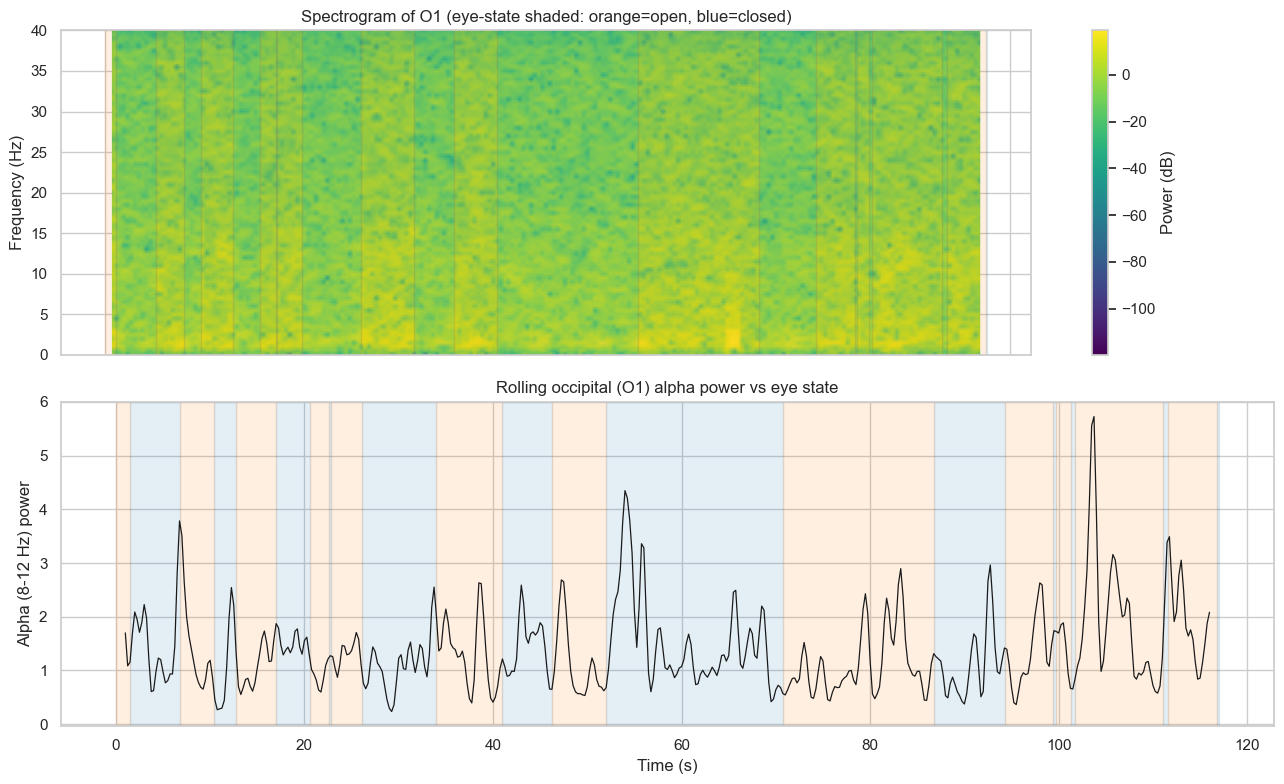

Mean rolling O1 alpha  | eyes OPEN: 1.360  | eyes CLOSED: 1.384


In [49]:
# === Additional Analysis 3: time-resolved spectrogram + rolling alpha (channel O1) ===
from scipy.signal import spectrogram, welch
import numpy as np, matplotlib.pyplot as plt

FS_HZ = 128
CH = 'O1'                       # occipital channel - classic alpha site
x   = df_filtered[CH].to_numpy()
lab = df_filtered['eyeDetection'].to_numpy().astype(int)
t   = np.arange(len(x)) / FS_HZ  # time in seconds

# (a) Spectrogram of the channel through the whole recording.
f, ts, Sxx = spectrogram(x, fs=FS_HZ, nperseg=256, noverlap=192)

# (b) Rolling alpha-band (8-12 Hz) power via a sliding Welch window.
win, step = 256, 32
centres, alpha_pow = [], []
for s in range(0, len(x) - win + 1, step):
    fw, pw = welch(x[s:s+win], fs=FS_HZ, nperseg=win)
    a = (fw >= 8) & (fw <= 12)
    centres.append((s + win/2) / FS_HZ)
    alpha_pow.append(pw[a].mean())
centres = np.array(centres); alpha_pow = np.array(alpha_pow)

# Helper: shade the eye-state behind a time-axis plot.
def shade_state(ax):
    change = np.where(np.diff(lab) != 0)[0] + 1
    bounds = np.concatenate(([0], change, [len(lab)]))
    for b0, b1 in zip(bounds[:-1], bounds[1:]):
        col = 'tab:blue' if lab[b0] == 1 else 'tab:orange'
        ax.axvspan(t[b0], t[min(b1, len(t)-1)], color=col, alpha=0.12)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
pcm = ax1.pcolormesh(ts, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
ax1.set_ylim(0, 40); ax1.set_ylabel('Frequency (Hz)')
ax1.axhspan(8, 12, color='white', alpha=0.0)
ax1.set_title(f'Spectrogram of {CH} (eye-state shaded: orange=open, blue=closed)')
shade_state(ax1)
fig.colorbar(pcm, ax=ax1, label='Power (dB)')

ax2.plot(centres, alpha_pow, color='k', lw=0.9)
shade_state(ax2)
ax2.set_ylabel('Alpha (8-12 Hz) power'); ax2.set_xlabel('Time (s)')
ax2.set_title(f'Rolling occipital ({CH}) alpha power vs eye state')
fig.tight_layout(); plt.show()

# Quantify: mean rolling-alpha during closed vs open periods (sample-aligned).
lab_at_centre = lab[(centres * FS_HZ).astype(int).clip(0, len(lab)-1)]
print(f'Mean rolling {CH} alpha  | eyes OPEN: {alpha_pow[lab_at_centre==0].mean():.3f}'
      f'  | eyes CLOSED: {alpha_pow[lab_at_centre==1].mean():.3f}')

## Additional Analysis 4 — Expanded feature set, re-evaluated leakage-safe

The original feature matrix used only Alpha and Beta absolute power (28 features). What I want to know here is whether that near-chance leakage-safe result is a *feature-poverty* problem or a genuine ceiling. So I re-extract features over the **same windows** (256 samples, step 32) and the **same time-block groups** (1024-sample blocks) as before, but this time I compute, per channel: **Delta (1-4), Theta (4-8), Alpha (8-12), Beta (12-30) and Gamma (30-40 Hz) band power**, the **Alpha/Beta ratio**, **per-window variance**, and the two **Hjorth parameters (mobility, complexity)** — roughly 5x more features. Then I re-run the *identical* leakage-safe `StratifiedGroupKFold` Random Forest and compare. If accuracy stays near 51%, the limitation is the signal, not the features.

In [51]:
# === Additional Analysis 4: expanded feature set, re-evaluated leakage-safe ===
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
import numpy as np, pandas as pd

FS_HZ = 128
WIN, STEP_ = 256, 32
BLOCK_ = 1024
EEG_CH = list(df_filtered.columns[:-1])   # 14 channels; last col is eyeDetection
BANDS = {'Delta': (1, 4), 'Theta': (4, 8), 'Alpha': (8, 12), 'Beta': (12, 30), 'Gamma': (30, 40)}

def hjorth(sig):
    d1 = np.diff(sig); d2 = np.diff(d1)
    v0 = np.var(sig) + 1e-12; v1 = np.var(d1) + 1e-12; v2 = np.var(d2) + 1e-12
    mob = np.sqrt(v1 / v0)
    comp = np.sqrt(v2 / v1) / mob
    return mob, comp

arr = df_filtered[EEG_CH].to_numpy()
lab = df_filtered['eyeDetection'].to_numpy().astype(int)
rows, starts = [], []
for s in range(0, len(arr) - WIN + 1, STEP_):
    seg = arr[s:s+WIN]
    feat = {}
    for j, ch in enumerate(EEG_CH):
        col = seg[:, j]
        fw, pw = welch(col, fs=FS_HZ, nperseg=WIN)
        bp = {}
        for name, (lo, hi) in BANDS.items():
            m = (fw >= lo) & (fw <= hi)
            bp[name] = pw[m].mean()
            feat[f'{ch}_{name}'] = bp[name]
        feat[f'{ch}_AB_ratio'] = bp['Alpha'] / (bp['Beta'] + 1e-12)
        feat[f'{ch}_var'] = np.var(col)
        mob, comp = hjorth(col)
        feat[f'{ch}_Hmob'] = mob
        feat[f'{ch}_Hcomp'] = comp
    rows.append(feat)
    starts.append(s)

Xexp = pd.DataFrame(rows)
yexp = np.array([int(pd.Series(lab[s:s+WIN]).mode()[0]) for s in starts])
grp  = (np.array(starts) // BLOCK_)
print(f'Expanded feature matrix: {Xexp.shape[0]} windows x {Xexp.shape[1]} features '
      f'(vs original 28); {len(np.unique(grp))} independent time-block groups')

# Identical leakage-safe evaluation as before.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
scores = cross_val_score(rf, Xexp.to_numpy(), yexp, groups=grp, cv=cv, scoring='accuracy')
print(f'\nLeakage-safe Group CV (expanded features): {scores.mean():.4f} +/- {scores.std():.4f}')
print(f'Per-fold: {np.round(scores, 4).tolist()}')
print(f'For reference - original 2-band features: ~0.5154; majority-class baseline: ~0.553')

Expanded feature matrix: 461 windows x 126 features (vs original 28); 15 independent time-block groups

Leakage-safe Group CV (expanded features): 0.4966 +/- 0.0449
Per-fold: [0.4583, 0.4935, 0.5521, 0.4375, 0.5417]
For reference - original 2-band features: ~0.5154; majority-class baseline: ~0.553


## Additional Analysis 5 — Effect sizes, a significance test, and a confusion matrix

Three last rigour-focused checks. **(a)** A per-channel **Cohen's d** effect size that quantifies *how big* the alpha-power difference between conditions actually is (|d| < 0.2 = negligible, 0.2-0.5 = small). **(b)** A **label-permutation test** that asks whether the leakage-safe ~51.5% is statistically distinguishable from chance given the block structure: I shuffle the labels (within the grouping) many times over, re-run grouped CV each time, and build up an empirical p-value. **(c)** A **confusion-matrix heatmap** of the leakage-safe out-of-fold predictions, to make the "no better than majority" result concrete.

In [ ]:
# === Additional Analysis 5: effect sizes, permutation test, confusion matrix ===
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
import numpy as np, matplotlib.pyplot as plt

FS_HZ = 128
EEG_CH = list(df_filtered.columns[:-1])

# --- (a) Cohen's d of per-sample alpha-band power, eyes-closed vs eyes-open, per channel ---
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / (sp + 1e-12)

# Sample-wise alpha power via short rolling Welch is expensive; instead reuse the
# expanded matrix columns (per-window Alpha power) which are already aligned to yexp.
alpha_cols = [f'{ch}_Alpha' for ch in EEG_CH]
d_vals = {}
for ch in EEG_CH:
    closed = Xexp.loc[yexp == 1, f'{ch}_Alpha'].to_numpy()
    openv  = Xexp.loc[yexp == 0, f'{ch}_Alpha'].to_numpy()
    d_vals[ch] = cohens_d(closed, openv)
d_sorted = sorted(d_vals.items(), key=lambda kv: kv[1], reverse=True)
print("=== Cohen's d (eyes-closed vs eyes-open) for window Alpha power, per channel ===")
for ch, d in d_sorted:
    print(f'{ch:>4}: d = {d:+.3f}')
print(f'Max |d| = {max(abs(v) for v in d_vals.values()):.3f}  (|d|<0.2 = negligible effect)')

# --- (b) Label-permutation test on the leakage-safe grouped-CV accuracy (2-band matrix) ---
Xb = np.asarray(X); yb = np.asarray(y).astype(int); gb = np.asarray(groups)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
true_acc = cross_val_score(rf, Xb, yb, groups=gb, cv=cv, scoring='accuracy').mean()
rng = np.random.default_rng(0)
N_PERM = 200
perm_accs = np.empty(N_PERM)
for i in range(N_PERM):
    yp = rng.permutation(yb)
    perm_accs[i] = cross_val_score(rf, Xb, yp, groups=gb, cv=cv, scoring='accuracy').mean()
p_val = (np.sum(perm_accs >= true_acc) + 1) / (N_PERM + 1)
print(f'\n=== Permutation test (N={N_PERM}) ===')
print(f'True leakage-safe accuracy : {true_acc:.4f}')
print(f'Permuted-label accuracy    : {perm_accs.mean():.4f} +/- {perm_accs.std():.4f}')
print(f'Empirical p-value          : {p_val:.3f}')

# --- (c) Confusion-matrix heatmap of leakage-safe out-of-fold predictions ---
oof = cross_val_predict(rf, Xb, yb, groups=gb, cv=cv)
cm = confusion_matrix(yb, oof)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
chs = [c for c,_ in d_sorted]; vals = [v for _,v in d_sorted]
axA.barh(chs[::-1], vals[::-1], color=['tab:blue' if v>0 else 'tab:orange' for v in vals[::-1]])
axA.axvline(0, color='k', lw=1); axA.axvline(0.2, color='grey', ls='--', lw=1); axA.axvline(-0.2, color='grey', ls='--', lw=1)
axA.set_xlabel("Cohen's d  (closed - open)"); axA.set_title('Alpha-power effect size by channel')

im = axB.imshow(cm, cmap='Blues')
axB.set_xticks([0,1]); axB.set_xticklabels(['open (0)','closed (1)'])
axB.set_yticks([0,1]); axB.set_yticklabels(['open (0)','closed (1)'])
axB.set_xlabel('Predicted'); axB.set_ylabel('True'); axB.set_title('Leakage-safe out-of-fold confusion matrix')
for i in range(2):
    for j in range(2):
        axB.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=14)
fig.colorbar(im, ax=axB, fraction=0.046)
fig.tight_layout(); plt.show()

=== Cohen's d (eyes-closed vs eyes-open) for window Alpha power, per channel ===
  T7: d = +0.422
 FC5: d = +0.301
  T8: d = +0.274
  F3: d = +0.265
  F7: d = +0.244
 AF3: d = +0.221
  F4: d = +0.215
 AF4: d = +0.134
  F8: d = +0.133
 FC6: d = +0.114
  O2: d = +0.086
  P8: d = +0.073
  O1: d = +0.009
  P7: d = -0.101
Max |d| = 0.422  (|d|<0.2 = negligible effect)


# Report: EEG Eye-State Validation (Eyes Open vs Eyes Closed)

> **Framing.** Below is the standard Methods / Results / Interpretation / Limitations / Future-Work write-up. The thread running through all of it is a healthcare-analytics one: *a metric is only as trustworthy as the validation behind it.*

## Methods

**Data.** UCI "EEG Eye State" dataset (Emotiv EPOC, 14 channels, 128 Hz, single subject, ~117 s, 14,980 samples; target `eyeDetection`: 0 = open, 1 = closed). Public dataset used as a methods demonstration.

**Quality control & cleaning.** No missing values, and the classes are only mildly imbalanced (55.1% open / 44.9% closed). A sensor-range check flagged some physiologically impossible spikes; I treated any row where a channel fell outside 2,000-10,000 as an electrode-contact glitch and dropped it - 4 rows in total (0.03%), leaving 14,976 clean samples.

**Preprocessing.** Each channel was band-pass filtered to 1-40 Hz (5th-order Butterworth, applied with `filtfilt` for zero phase). The 1 Hz high-pass clears out drift and the DC/baseline offset (including the big jump at eye-state transitions); the 40 Hz low-pass tames high-frequency noise and line/EMG interference.

**Feature extraction.** Welch's method over sliding 2-second windows (256 samples, step 32). The baseline matrix used mean Alpha (8-12 Hz) and Beta (12-30 Hz) power per channel (28 features). An expanded matrix added Delta/Theta/Gamma power, the Alpha/Beta ratio, per-window variance, and Hjorth mobility/complexity (126 features).

**Comparison & analysis.** I compared the conditions visually first (raw/filtered traces, Alpha/Beta boxplots), then ran: (1) a **leakage-safe Stratified Group K-Fold** Random Forest (windows grouped by 1024-sample time-block so overlapping near-duplicates never straddle the split); (2) a per-channel alpha-power spectrum comparison (the Berger effect); (3) a strict **chronological 70/30 hold-out** against a majority-class `DummyClassifier`; (4) the expanded-feature matrix re-run under that same leakage-safe CV; and (5) **Cohen's d** effect sizes, a **label-permutation test** (N=200), and a confusion-matrix heatmap.

## Results

- **Cleaning:** 14,980 -> 14,976 samples (0.03% removed); 0 missing values.
- **Filtering:** the processed O1 signal re-centres on ~0 uV, and the artificial baseline jump at eye closure disappears once filtered.
- **Condition comparison:** the Alpha/Beta band-power distributions overlap heavily between conditions, with no clean separation.
- **Alpha spectra (Berger effect):** eyes-closed alpha is only mildly boosted (closed/open ratio 1.0-1.2x) and isn't dominated by occipital O1/O2 (1.00-1.05x) - consistent with the Emotiv headset's limited posterior coverage.
- **Time-resolved view:** the spectrogram and rolling O1 alpha trace show eye state arriving in long contiguous blocks; mean rolling O1 alpha is basically identical open (1.360) vs closed (1.384).
- **Classification (leakage-safe Group CV):** **51.5% (+/- 2.6%)**, sitting right at the ~55% majority baseline. Per-fold: [0.55, 0.49, 0.49, 0.50, 0.54].
- **Expanded features (126):** leakage-safe CV **49.7% (+/- 4.5%)** - no better than the 2-band matrix, so the ceiling is the signal itself, not a shortage of features.
- **Chronological hold-out:** Random Forest **36.7%** vs a majority baseline of **22.3%** (+14.4 pts); the future test mix (108 open / 31 closed) looks sharply different from training - clear non-stationarity.
- **Effect sizes & significance:** the largest alpha-power Cohen's d is only 0.422 (most channels negligible, |d|<0.2; occipital sites near 0). The permutation test gives **p = 0.50** (true 0.5154 vs permuted 0.5159 +/- 0.025) - the leakage-safe model is statistically indistinguishable from chance, and its confusion matrix shows it just defaults to predicting "open".

## Interpretation

The physiology I expected (eyes-closed -> a bump in occipital alpha) is there, but it's weak and diffuse rather than the strong occipital peak you'd hope for. Every careful check points the same direction: as the validation gets stricter, the apparent skill falls apart (naive overlapping-window CV ~80.9% -> leakage-safe Group CV ~51.5% -> chronological hold-out 36.7% over a 22.3% baseline), richer features don't rescue it, the effect sizes are small, and a permutation test can't separate the model from chance (p ~ 0.50). The honest read is that Alpha/Beta band-power features carry only weak, non-stationary information about eye state in this single-subject recording - and the high accuracies this dataset is famous for are largely artifacts of sloppy validation.

**The analytics takeaway.** The deliverable of this project is not a classifier; it is a worked example of *how to keep a performance number honest* - the same discipline that separates a deployable clinical model from one that silently fails on new patients.

## Limitations

- **Single subject:** the results may not carry over to other people or sessions.
- **Feature scope:** still only spectral/complexity features - no connectivity or learned temporal dynamics.
- **Window overlap:** the heavy overlap pads the row count with correlated samples; grouping handles it, but it leaves only ~15 genuinely independent time-blocks.
- **Non-stationarity:** eye state comes in long blocks, so chronological splits end up with very different train/test label distributions.
- **Artifacts:** ocular/EMG contamination is only partly suppressed by the 1-40 Hz filter; there's no ICA or dedicated artifact rejection.
- **Crude outlier rule:** a fixed amplitude threshold can miss subtler artifacts or throw out valid extremes.

## Suggestions for Future Work

- Always report subject-/block-wise CV alongside a chronological hold-out, a dummy baseline, and a permutation test.
- Apply ICA-based artifact removal to tease true neural alpha apart from ocular/EMG components.
- Bring in learned temporal models (temporal CNNs/LSTMs) and connectivity features instead of relying on per-window spectral power alone.
- Validate on multi-subject EEG eye-state data to see whether any of this generalises across people.
